# Car Price Prediction using Machine Learning

## Objective
The objective of this project is to predict the selling price of used cars based on various features such as present price, fuel type, kilometers driven, transmission type, and ownership using Machine Learning regression techniques.

## Importing the required libraries

In [75]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the dataset

In [94]:
df= pd.read_csv(r"C:\Users\Nandana\Downloads\archive (5)\car data.csv")
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


## Understanding the dataset


In [95]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.columns)

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.1000

## Categorical columns identified: 

- Fuel_type
- Seller_type
- Transmission

## Data preprocessing

### Removing car column name

In [96]:
df = df.drop(['Car_Name'], axis=1)

## Encoding

In [97]:
df = pd.get_dummies(df, drop_first=True)
print(df.head())

   Year  Selling_Price  Present_Price  Driven_kms  Owner  Fuel_Type_Diesel  \
0  2014           3.35           5.59       27000      0             False   
1  2013           4.75           9.54       43000      0              True   
2  2017           7.25           9.85        6900      0             False   
3  2011           2.85           4.15        5200      0             False   
4  2014           4.60           6.87       42450      0              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
0              True                    False                 True  
1             False                    False                 True  
2              True                    False                 True  
3              True                    False                 True  
4             False                    False                 True  


## Exploratory Data Analysis

### Correlation heatmap

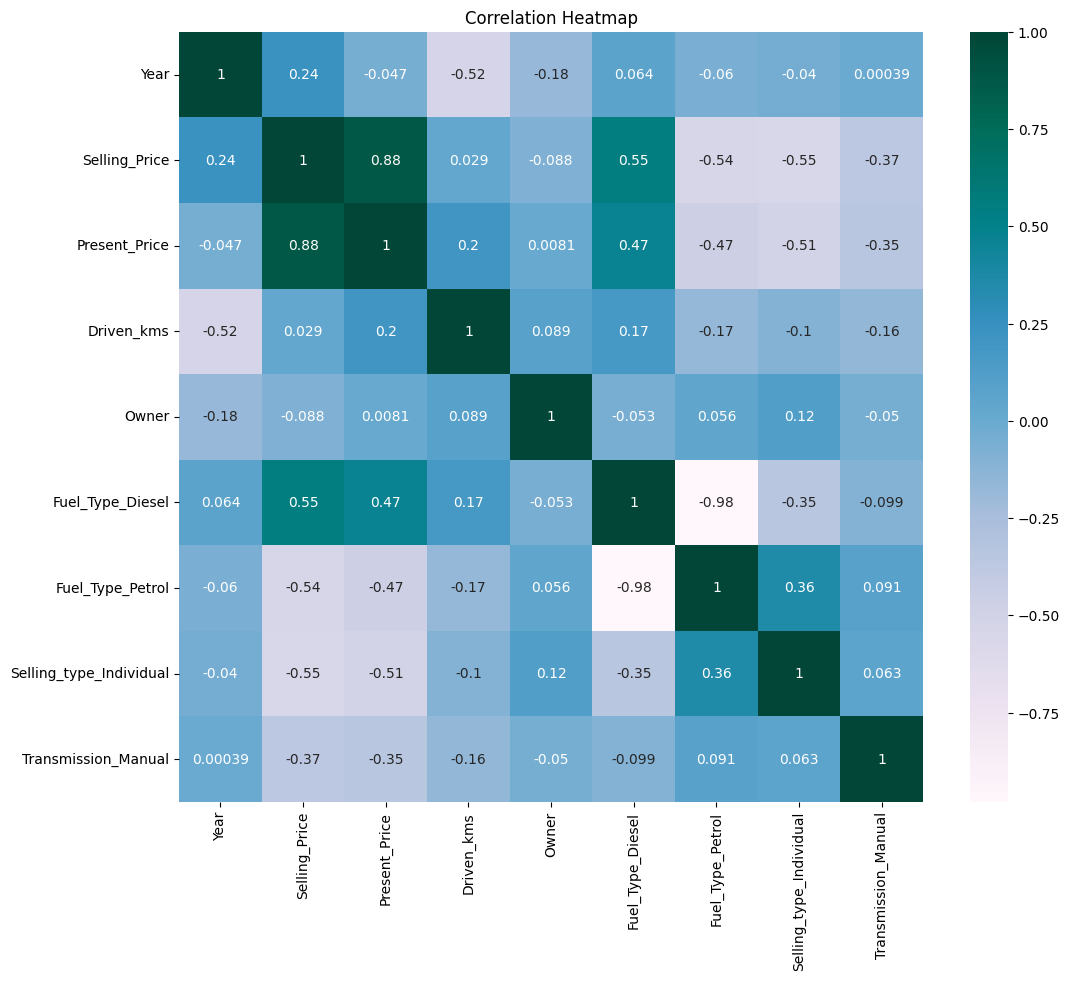

In [110]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), annot=True, cmap='PuBuGn')

plt.title("Correlation Heatmap")

plt.show()

## Observations

- Present Price has a strong positive correlation with Selling Price.
- Cars with higher present market value tend to have higher resale value.
- Kms Driven shows a negative correlation with Selling Price, indicating that heavily driven cars usually have lower resale prices.
- Fuel type and transmission also influence the selling price of cars.

## Data Visualization

### Selling Price Distribution

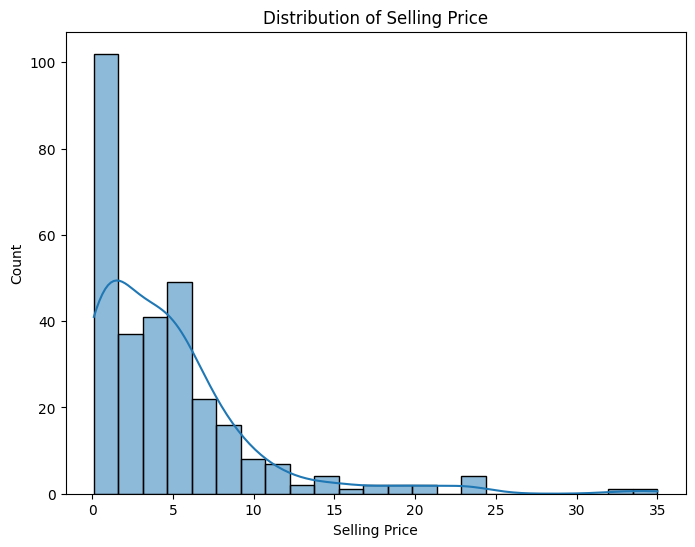

In [111]:
plt.figure(figsize=(8,6))

sns.histplot(df['Selling_Price'], kde=True)

plt.title("Distribution of Selling Price")

plt.xlabel("Selling Price")

plt.show()

### Observation

The distribution shows that most cars have lower selling prices, while only a few cars have very high selling prices.

### Present Price vs Selling Price

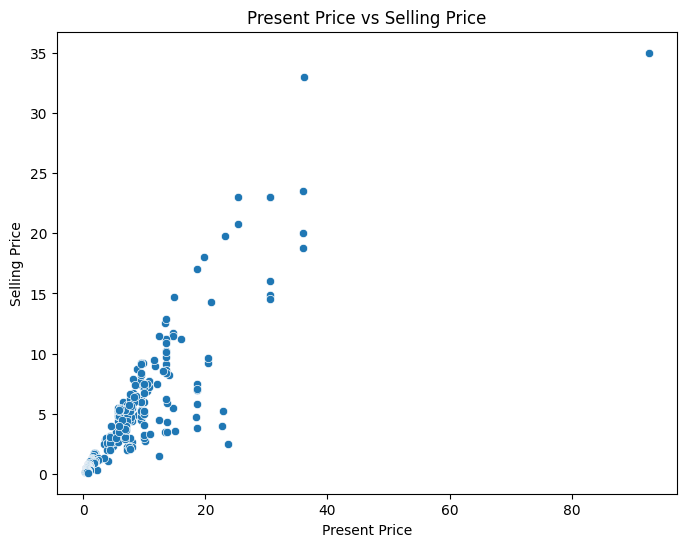

In [112]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)

plt.title("Present Price vs Selling Price")

plt.xlabel("Present Price")

plt.ylabel("Selling Price")

plt.show()

### Observation

A strong positive linear relationship can be observed between Present Price and Selling Price. Cars with higher current market prices generally have higher resale values.

## Feature Selection

In [113]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

## Train-Test Split

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model Training using Linear Regression

In [115]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Making Predictions

In [116]:
y_pred = model.predict(X_test)

## Model Evaluation


In [117]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.216374019332988


In [118]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 3.481349830510787


In [119]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8488707839193601


## Evaluation Metrics Explanation

- Mean Absolute Error (MAE) measures the average prediction error.
- Mean Squared Error (MSE) penalizes larger prediction errors.
- R² Score indicates how well the model explains the variation in Selling Price values.

A higher R² Score and lower error values indicate better model performance.

## Actual vs Predicted Table

In [120]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head()

,Actual Price,Predicted Price
177,0.35,2.954337
289,10.11,8.177163
228,4.95,6.456123
198,0.15,-1.423372
60,6.95,9.088647


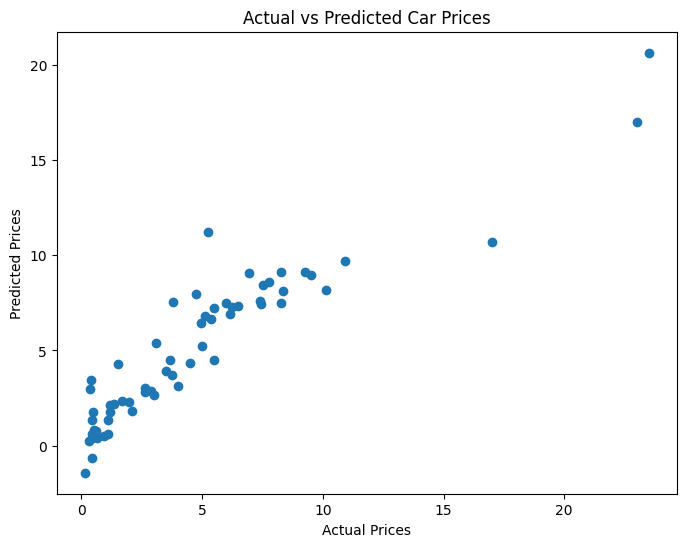

In [121]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

### Observation

The predicted values are close to the actual values, indicating that the Linear Regression model performs well for car price prediction.

## Conclusion

This project successfully implemented Linear Regression to predict car selling prices based on various car features.

The analysis revealed that Present Price has the strongest influence on Selling Price, while factors such as kilometers driven, fuel type, and transmission also contribute to price prediction.

This project helped in understanding:
- Data preprocessing
- Categorical variable encoding
- Exploratory Data Analysis
- Regression modeling
- Predictive analytics using Machine Learning